# O2O优惠券核销预测——模型构建与评估

基于前期构建的19个无泄漏特征，采用时间划分后的训练集和验证集建立优惠券核销预测模型，并通过ROC-AUC、Precision、Recall、F1等指标评估模型效果，为后续高潜用户识别与精准营销策略提供依据。

## 1. 建模数据读取与检查

读取特征工程阶段生成的训练集和验证集，并检查数据规模、特征数量及目标变量分布。

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/processed")
FIGURE_DIR = Path("../output/figures")
TABLE_DIR = Path("../output/tables")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# 中文字体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 读取训练集和验证集
train_model = pd.read_parquet(
    DATA_DIR / "train_model.parquet"
)

valid_model = pd.read_parquet(
    DATA_DIR / "valid_model.parquet"
)

print("训练集：", train_model.shape)
print("验证集：", valid_model.shape)

训练集： (746969, 20)
验证集： (215348, 20)


In [49]:
print("训练集字段：")

for i, col in enumerate(train_model.columns, 1):
    print(f"{i:02d}. {col}")

训练集字段：
01. is_manjian
02. discount_rate_value
03. discount_threshold
04. discount_reduction
05. distance_missing
06. distance_value
07. receive_month
08. receive_day
09. receive_weekday
10. is_weekend
11. user_mature_coupon_count
12. user_mature_redeem_count
13. user_mature_redeem_rate
14. merchant_mature_coupon_count
15. merchant_mature_redeem_count
16. merchant_mature_redeem_rate
17. coupon_mature_receive_count
18. coupon_mature_redeem_count
19. coupon_mature_redeem_rate
20. label


In [50]:
# 划分模型输入特征和目标变量
X_train = train_model.drop(columns=["label"])
y_train = train_model["label"]

X_valid = valid_model.drop(columns=["label"])
y_valid = valid_model["label"]

print("X_train：", X_train.shape)
print("y_train：", y_train.shape)

print("\nX_valid：", X_valid.shape)
print("y_valid：", y_valid.shape)

print("\n训练集正样本率：", f"{y_train.mean():.2%}")
print("验证集正样本率：", f"{y_valid.mean():.2%}")

X_train： (746969, 19)
y_train： (746969,)

X_valid： (215348, 19)
y_valid： (215348,)

训练集正样本率： 4.86%
验证集正样本率： 10.02%


## 2. Logistic Regression 基线模型

首先使用逻辑回归建立基线模型。由于优惠券核销样本存在明显的类别不平衡，本项目不以准确率作为主要评价指标，而重点关注ROC-AUC、Precision、Recall和F1等指标。

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 建立逻辑回归基线模型
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print(logistic_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [52]:
# 训练逻辑回归模型
logistic_model.fit(X_train, y_train)

print("Logistic Regression 训练完成")

Logistic Regression 训练完成


In [53]:
# 预测验证集
y_valid_pred = logistic_model.predict(X_valid)

# 预测属于“15天内核销”的概率
y_valid_prob = logistic_model.predict_proba(X_valid)[:, 1]

print("预测完成")

print("\n前10个预测类别：")
print(y_valid_pred[:10])

print("\n前10个核销概率：")
print(y_valid_prob[:10])

预测完成

前10个预测类别：
[0 0 0 0 0 0 0 0 0 0]

前10个核销概率：
[0.18835839 0.01889339 0.1228481  0.30896339 0.2894173  0.12614098
 0.05446621 0.12567426 0.11838037 0.11912074]


## 3. Logistic Regression 模型评估

从Accuracy、Precision、Recall、F1和ROC-AUC等指标综合评估逻辑回归基线模型，并结合类别不平衡问题分析模型对优惠券核销用户的识别能力。

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# 计算模型评价指标
accuracy = accuracy_score(y_valid, y_valid_pred)
precision = precision_score(
    y_valid, y_valid_pred, zero_division=0
)
recall = recall_score(
    y_valid, y_valid_pred, zero_division=0
)
f1 = f1_score(
    y_valid, y_valid_pred, zero_division=0
)
roc_auc = roc_auc_score(y_valid, y_valid_prob)

print("Logistic Regression 验证集结果")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Logistic Regression 验证集结果
----------------------------------------
Accuracy  : 0.8975
Precision : 0.4114
Recall    : 0.0535
F1-score  : 0.0946
ROC-AUC   : 0.6434


In [55]:
# 混淆矩阵
cm = confusion_matrix(y_valid, y_valid_pred)

cm_df = pd.DataFrame(
    cm,
    index=["实际未核销", "实际核销"],
    columns=["预测未核销", "预测核销"]
)

cm_df

,预测未核销,预测核销
实际未核销,192117,1651
实际核销,20426,1154


## 4. 分类阈值分析

由于核销样本占比较低，默认0.5分类阈值可能导致模型过度倾向于预测未核销。本节比较不同分类阈值下Precision、Recall和F1的变化，寻找更适合优惠券核销识别场景的分类阈值。

In [56]:
# 比较不同分类阈值下的模型表现
threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.05):

    pred = (y_valid_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_valid, pred, zero_division=0
        ),
        "recall": recall_score(
            y_valid, pred, zero_division=0
        ),
        "f1": f1_score(
            y_valid, pred, zero_division=0
        ),
        "predicted_positive_rate": pred.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,threshold,precision,recall,f1,predicted_positive_rate
0,0.05,0.1179,0.9234,0.2091,0.7847
1,0.10,0.1321,0.8098,0.2271,0.6143
2,0.15,0.1383,0.6557,0.2284,0.4750
3,0.20,0.1449,0.4380,0.2177,0.3030
4,0.25,0.1686,0.2670,0.2067,0.1587
5,0.30,0.2066,0.1763,0.1903,0.0855
6,0.35,0.2515,0.1247,0.1667,0.0497
7,0.40,0.2806,0.0937,0.1405,0.0335
8,0.45,0.3420,0.0709,0.1175,0.0208
9,0.50,0.4114,0.0535,0.0946,0.0130


In [57]:
# 找到F1最高的分类阈值
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("F1最优阈值：")
print(best_threshold_row.round(4))

F1最优阈值：
threshold                  0.1500
precision                  0.1383
recall                     0.6557
f1                         0.2284
predicted_positive_rate    0.4750
Name: 2, dtype: float64


## 5. Random Forest 模型

为进一步捕捉优惠券核销行为中的非线性关系及特征交互，本节构建随机森林模型，并与Logistic Regression基线模型进行比较。

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest 训练完成")

Random Forest 训练完成


In [59]:
# Random Forest 验证集预测
rf_valid_pred = rf_model.predict(X_valid)

rf_valid_prob = rf_model.predict_proba(
    X_valid
)[:, 1]

print("Random Forest 预测完成")

print("\n前10个预测类别：")
print(rf_valid_pred[:10])

print("\n前10个核销概率：")
print(rf_valid_prob[:10])

Random Forest 预测完成

前10个预测类别：
[1 1 1 1 1 1 1 1 1 1]

前10个核销概率：
[0.75233985 0.62372691 0.71294589 0.83173311 0.82613203 0.61034279
 0.51524839 0.58137496 0.62384804 0.61155714]


In [60]:
rf_accuracy = accuracy_score(
    y_valid, rf_valid_pred
)

rf_precision = precision_score(
    y_valid, rf_valid_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_valid, rf_valid_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_valid, rf_valid_pred,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_valid, rf_valid_prob
)

print("Random Forest 验证集结果")
print("-" * 40)
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

Random Forest 验证集结果
----------------------------------------
Accuracy  : 0.4211
Precision : 0.1365
Recall    : 0.8970
F1-score  : 0.2370
ROC-AUC   : 0.7376


## 6. Random Forest 特征重要性分析

通过Random Forest模型的特征重要性分析，识别对优惠券核销预测影响较大的特征，为后续模型解释和营销策略分析提供参考。

In [62]:
# Random Forest 特征重要性
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,distance_value,0.245479
1,discount_threshold,0.168860
2,discount_reduction,0.118891
3,receive_month,0.107445
4,merchant_mature_coupon_count,0.073563
5,discount_rate_value,0.051431
6,merchant_mature_redeem_rate,0.042317
7,merchant_mature_redeem_count,0.041185
8,receive_day,0.035299
9,coupon_mature_receive_count,0.029728


## 7. LightGBM 模型

进一步采用LightGBM梯度提升模型捕捉复杂的非线性关系，并与Logistic Regression和Random Forest进行效果对比。

In [63]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

print("LightGBM 训练完成")

LightGBM 训练完成


In [64]:
# LightGBM 验证集预测
lgb_valid_pred = lgb_model.predict(X_valid)

lgb_valid_prob = lgb_model.predict_proba(
    X_valid
)[:, 1]

print("LightGBM 预测完成")

print("\n前10个预测类别：")
print(lgb_valid_pred[:10])

print("\n前10个核销概率：")
print(lgb_valid_prob[:10])

LightGBM 预测完成

前10个预测类别：
[0 0 0 0 0 0 0 0 0 0]

前10个核销概率：
[0.13583868 0.06541855 0.07660457 0.25943634 0.25306556 0.06158986
 0.02889987 0.05765585 0.08501683 0.05100821]


In [65]:
lgb_accuracy = accuracy_score(
    y_valid, lgb_valid_pred
)

lgb_precision = precision_score(
    y_valid, lgb_valid_pred,
    zero_division=0
)

lgb_recall = recall_score(
    y_valid, lgb_valid_pred,
    zero_division=0
)

lgb_f1 = f1_score(
    y_valid, lgb_valid_pred,
    zero_division=0
)

lgb_auc = roc_auc_score(
    y_valid, lgb_valid_prob
)

print("LightGBM 验证集结果")
print("-" * 40)
print(f"Accuracy  : {lgb_accuracy:.4f}")
print(f"Precision : {lgb_precision:.4f}")
print(f"Recall    : {lgb_recall:.4f}")
print(f"F1-score  : {lgb_f1:.4f}")
print(f"ROC-AUC   : {lgb_auc:.4f}")

LightGBM 验证集结果
----------------------------------------
Accuracy  : 0.9013
Precision : 0.6024
Recall    : 0.0446
F1-score  : 0.0830
ROC-AUC   : 0.7165


## 8. 三种模型效果对比

综合比较Logistic Regression、Random Forest和LightGBM在时间验证集上的预测效果，重点关注ROC-AUC、Precision、Recall和F1等指标，以确定后续高潜用户识别所采用的模型。

In [66]:
# 三种模型效果对比
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        lgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        lgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        lgb_recall
    ],
    "F1": [
        f1,
        rf_f1,
        lgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_auc,
        lgb_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8975,0.4114,0.0535,0.0946,0.6434
1,Random Forest,0.4211,0.1365,0.8970,0.2370,0.7376
2,LightGBM,0.9013,0.6024,0.0446,0.0830,0.7165


In [67]:
model_comparison.to_csv(
    TABLE_DIR / "model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("模型对比结果已保存")

模型对比结果已保存


## 9. LightGBM 高潜用户识别与营销策略分析

基于LightGBM输出的核销概率，对验证集样本进行高潜用户排序，并比较不同Top-K触达比例下的实际核销率与提升效果，从而模拟有限营销资源下的精准投放策略。

In [68]:
# 构建高潜用户分析数据
marketing_result = valid_model.copy()

marketing_result["pred_prob"] = lgb_valid_prob

marketing_result = (
    marketing_result
    .sort_values("pred_prob", ascending=False)
    .reset_index(drop=True)
)

marketing_result[["label", "pred_prob"]].head(10)

,label,pred_prob
0,1,0.966793
1,1,0.959681
2,1,0.958000
3,1,0.958000
4,1,0.958000
5,1,0.954998
6,1,0.954998
7,1,0.954998
8,1,0.954998
9,1,0.953259


In [69]:
print("验证集样本数：", len(marketing_result))
print(
    "验证集整体实际核销率：",
    f"{marketing_result['label'].mean():.2%}"
)

print("\n预测概率最高的前10条：")
print(
    marketing_result[
        ["label", "pred_prob"]
    ].head(10)
)

验证集样本数： 215348
验证集整体实际核销率： 10.02%

预测概率最高的前10条：
   label  pred_prob
0      1   0.966793
1      1   0.959681
2      1   0.958000
3      1   0.958000
4      1   0.958000
5      1   0.954998
6      1   0.954998
7      1   0.954998
8      1   0.954998
9      1   0.953259


### 9.1 Top-K 高潜样本分析

按照LightGBM预测核销概率从高到低排序，分别选取Top 10%、Top 20%和Top 30%的高潜样本，计算其实际核销率，并与验证集整体核销率进行比较，以评估精准营销策略的潜在提升效果。

In [70]:
# 验证集整体核销率
overall_rate = marketing_result["label"].mean()

topk_results = []

for top_ratio in [0.1, 0.2, 0.3]:
    
    # 对应Top-K样本数量
    top_n = int(len(marketing_result) * top_ratio)
    
    # 取预测概率最高的Top-K样本
    top_data = marketing_result.head(top_n)
    
    # 实际核销率
    redemption_rate = top_data["label"].mean()
    
    # Lift：相对于整体平均核销率的提升倍数
    lift = redemption_rate / overall_rate
    
    # 捕获到的真实核销样本占全部真实核销样本的比例
    capture_rate = (
        top_data["label"].sum()
        / marketing_result["label"].sum()
    )
    
    topk_results.append({
        "Top比例": f"Top {int(top_ratio * 100)}%",
        "触达样本数": top_n,
        "实际核销数": int(top_data["label"].sum()),
        "实际核销率": redemption_rate,
        "Lift": lift,
        "核销用户捕获率": capture_rate
    })

topk_df = pd.DataFrame(topk_results)

topk_df

,Top比例,触达样本数,实际核销数,实际核销率,Lift,核销用户捕获率
0,Top 10%,21534,5445,0.252856,2.523263,0.252317
1,Top 20%,43069,8901,0.206668,2.062355,0.412465
2,Top 30%,64604,11954,0.185035,1.846474,0.553939


### 9.2 精准营销核销率提升效果

通过比较不同Top-K高潜样本的实际核销率与验证集整体核销率，分析模型筛选对优惠券精准营销效率的提升效果。

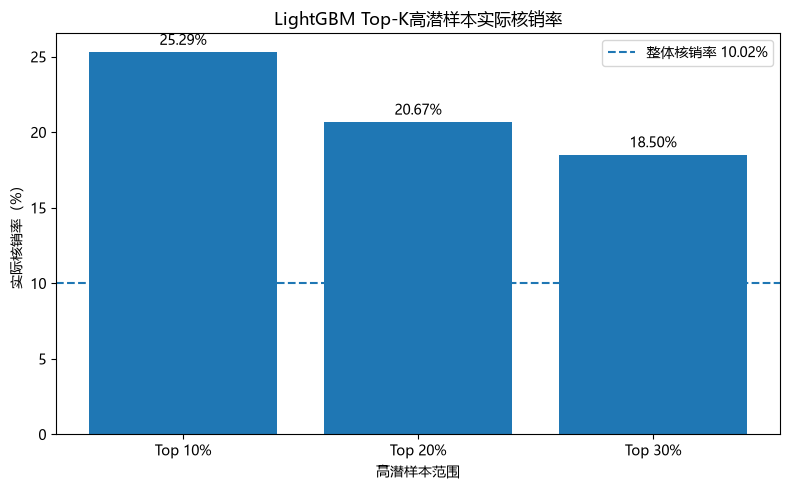

In [71]:
# 准备绘图数据
plot_df = topk_df.copy()

plot_df["核销率(%)"] = (
    plot_df["实际核销率"] * 100
)

overall_rate_pct = overall_rate * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_df["Top比例"],
    plot_df["核销率(%)"]
)

# 整体平均核销率
ax.axhline(
    y=overall_rate_pct,
    linestyle="--",
    label=f"整体核销率 {overall_rate_pct:.2f}%"
)

# 柱子上显示具体数值
for bar, value in zip(
    bars,
    plot_df["核销率(%)"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

ax.set_title("LightGBM Top-K高潜样本实际核销率")
ax.set_xlabel("高潜样本范围")
ax.set_ylabel("实际核销率（%）")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "10_topk_redemption_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.3 Lift与核销用户捕获率分析

进一步比较不同Top-K触达范围下的Lift和核销用户捕获率。其中，Lift衡量高潜样本核销率相对于整体平均水平的提升倍数，核销用户捕获率衡量有限触达范围能够覆盖多少实际核销样本。

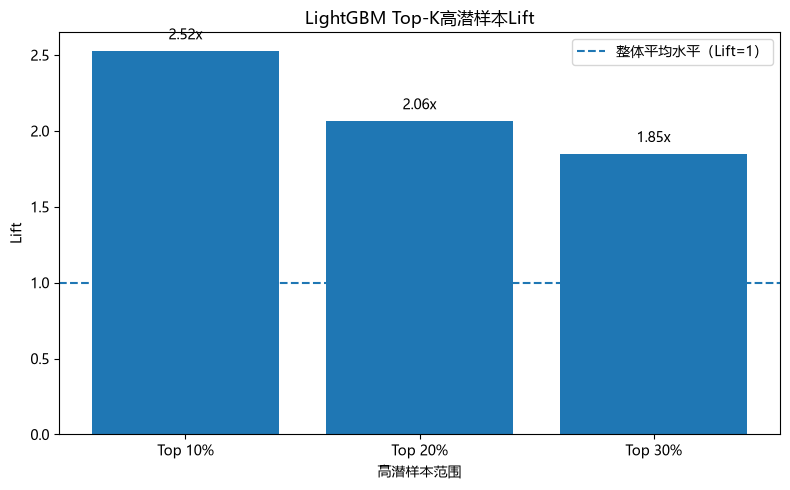

In [72]:
# 不同Top-K范围的Lift
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    topk_df["Top比例"],
    topk_df["Lift"]
)

for bar, value in zip(
    bars,
    topk_df["Lift"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{value:.2f}x",
        ha="center"
    )

ax.axhline(
    y=1,
    linestyle="--",
    label="整体平均水平（Lift=1）"
)

ax.set_title("LightGBM Top-K高潜样本Lift")
ax.set_xlabel("高潜样本范围")
ax.set_ylabel("Lift")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "11_topk_lift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

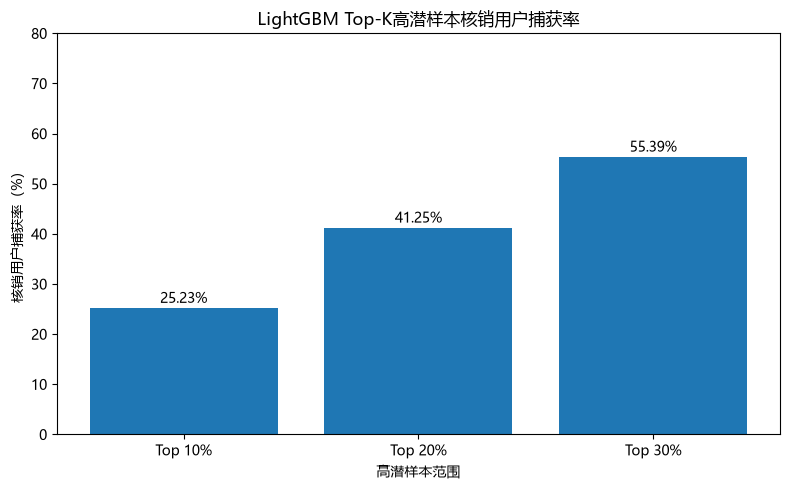

In [73]:
# 不同Top-K范围的核销用户捕获率
capture_pct = (
    topk_df["核销用户捕获率"] * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    topk_df["Top比例"],
    capture_pct
)

for bar, value in zip(
    bars,
    capture_pct
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

ax.set_title("LightGBM Top-K高潜样本核销用户捕获率")
ax.set_xlabel("高潜样本范围")
ax.set_ylabel("核销用户捕获率（%）")
ax.set_ylim(0, 80)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "12_topk_capture_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.4 营销策略分析结论

LightGBM能够有效识别高核销倾向样本。验证集整体核销率为10.02%，模型筛选出的Top 10%高潜样本实际核销率达到25.29%，Lift为2.52，仅触达10%的样本即可覆盖25.23%的实际核销样本。

随着触达范围扩大，Top 20%和Top 30%分别能够覆盖41.25%和55.39%的实际核销样本，但Lift由2.06下降至1.85，说明扩大营销覆盖范围能够提高实际核销用户的覆盖程度，但边际投放效率逐渐下降。因此，在营销预算有限时可优先触达Top 10%高潜样本；若需要兼顾投放效率与用户覆盖，可将Top 20%作为重点触达范围。

In [74]:
topk_df.to_csv(
    TABLE_DIR / "topk_marketing_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Top-K营销分析结果已保存")

Top-K营销分析结果已保存


## 10. LightGBM 特征重要性分析

为进一步解释模型的预测依据，对LightGBM模型的特征重要性进行分析，识别影响优惠券核销预测的关键特征，并结合前期探索性分析结果进行业务解释。

In [75]:
# 提取LightGBM特征重要性
lgb_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
})

lgb_feature_importance = (
    lgb_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

lgb_feature_importance

,feature,importance
0,merchant_mature_coupon_count,1176
1,receive_day,934
2,merchant_mature_redeem_rate,832
3,merchant_mature_redeem_count,724
4,distance_value,641
5,coupon_mature_receive_count,612
6,discount_rate_value,604
7,discount_threshold,524
8,receive_month,508
9,user_mature_coupon_count,496


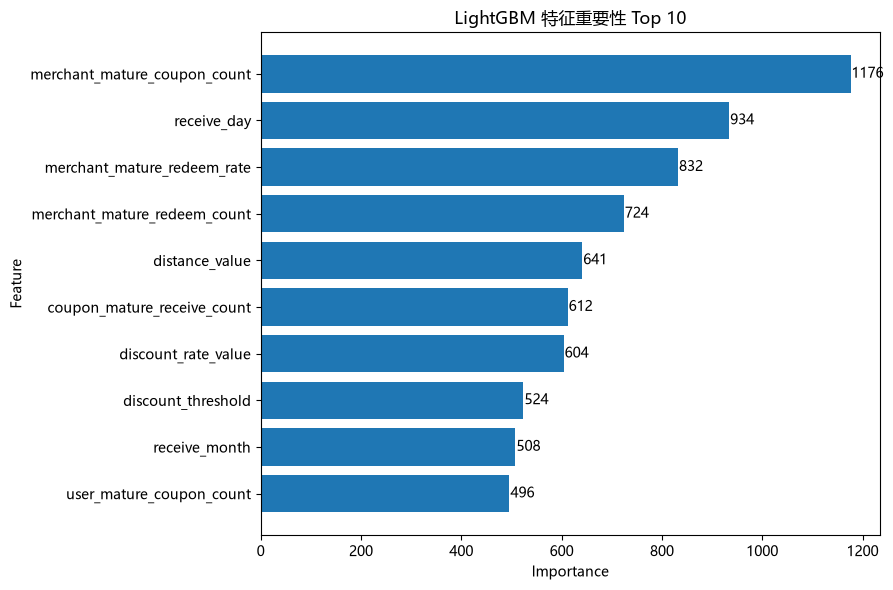

In [76]:
# LightGBM特征重要性Top 10
lgb_top10 = (
    lgb_feature_importance
    .head(10)
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    lgb_top10["feature"],
    lgb_top10["importance"]
)

for bar, value in zip(
    bars,
    lgb_top10["importance"]
):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{value}",
        va="center"
    )

ax.set_title("LightGBM 特征重要性 Top 10")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "13_lgb_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
lgb_feature_importance.to_csv(
    TABLE_DIR / "lgb_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("LightGBM特征重要性结果已保存")

LightGBM特征重要性结果已保存


### 10.1 特征重要性分析结论

LightGBM特征重要性结果显示，模型预测同时利用了领券时点、消费距离、优惠券历史表现、商户历史表现、用户历史行为和优惠力度等多维信息。其中，receive_day、distance_value以及多项商户和优惠券历史特征具有较高的重要性。

结合前期EDA结果可以发现，消费距离、优惠力度及优惠门槛等因素与核销行为存在明显关联；同时，优惠券和商户的历史核销表现也为模型识别高潜核销样本提供了重要信息。整体来看，优惠券核销倾向并非由单一因素决定，而是用户、商户、优惠券及消费场景等多类特征共同作用的结果。